In [1]:
!pip install openpyxl
!pip install matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
np.random.seed(1)
COUNT = 100

dates = pd.date_range(start="2050-01-01", periods=COUNT, freq="D")
products = np.random.choice(["Tablet", "Camera", "Phone", "Mic", "Keyboard"], COUNT)
prices = np.round(np.random.uniform(50.0, 200.0, COUNT), 2)
qty = np.random.randint(1, 15, COUNT)
data = {
    "Date": dates,
    "Product": products,
    "Price": prices,
    "Qty": qty
}

df = pd.DataFrame(data)
df.head()

,Date,Product,Price,Qty
0,2050-01-01,Mic,147.16,7
1,2050-01-02,Keyboard,103.09,10
2,2050-01-03,Tablet,164.48,7
3,2050-01-04,Camera,103.48,1
4,2050-01-05,Mic,162.92,1


In [4]:
df.to_csv("orders.csv", index=False)
dfCsv = pd.read_csv("orders.csv", parse_dates=["Date"], date_format="%Y-%m-%d")
dfCsv.head()

,Date,Product,Price,Qty
0,2050-01-01,Mic,147.16,7
1,2050-01-02,Keyboard,103.09,10
2,2050-01-03,Tablet,164.48,7
3,2050-01-04,Camera,103.48,1
4,2050-01-05,Mic,162.92,1


In [5]:
df.to_excel("orders.xlsx")
dfExcel = pd.read_excel("orders.xlsx")
dfExcel

,Unnamed: 0,Date,Product,Price,Qty
0,0,2050-01-01,Mic,147.16,7
1,1,2050-01-02,Keyboard,103.09,10
2,2,2050-01-03,Tablet,164.48,7
3,3,2050-01-04,Camera,103.48,1
4,4,2050-01-05,Mic,162.92,1
...,...,...,...,...,...
95,95,2050-04-06,Phone,119.32,8
96,96,2050-04-07,Tablet,69.84,7
97,97,2050-04-08,Phone,164.64,3
98,98,2050-04-09,Keyboard,81.91,11


In [6]:
df.to_json("orders.json")
dfJson = pd.read_json("orders.json")
dfJson

,Date,Product,Price,Qty
0,2050-01-01,Mic,147.16,7
1,2050-01-02,Keyboard,103.09,10
2,2050-01-03,Tablet,164.48,7
3,2050-01-04,Camera,103.48,1
4,2050-01-05,Mic,162.92,1
...,...,...,...,...
95,2050-04-06,Phone,119.32,8
96,2050-04-07,Tablet,69.84,7
97,2050-04-08,Phone,164.64,3
98,2050-04-09,Keyboard,81.91,11


In [7]:
df.describe().round(2)

,Date,Price,Qty
count,100,100.00,100.00
mean,2050-02-19 12:00:00,117.32,7.79
min,2050-01-01 00:00:00,51.35,1.00
25%,2050-01-25 18:00:00,81.13,5.00
50%,2050-02-19 12:00:00,114.10,8.00
75%,2050-03-16 06:00:00,161.21,11.25
max,2050-04-10 00:00:00,197.26,14.00
std,NaN,42.47,4.03


In [8]:
# Group qty by product
sales = df.groupby("Product")["Qty"].sum()
sales

Product
Camera      186
Keyboard    173
Mic         106
Phone       124
Tablet      190
Name: Qty, dtype: int32

In [9]:
avg_prices = df.groupby("Product")["Price"].mean().round(2)
avg_prices

Product
Camera      121.54
Keyboard    115.61
Mic         129.43
Phone       123.47
Tablet      100.17
Name: Price, dtype: float64

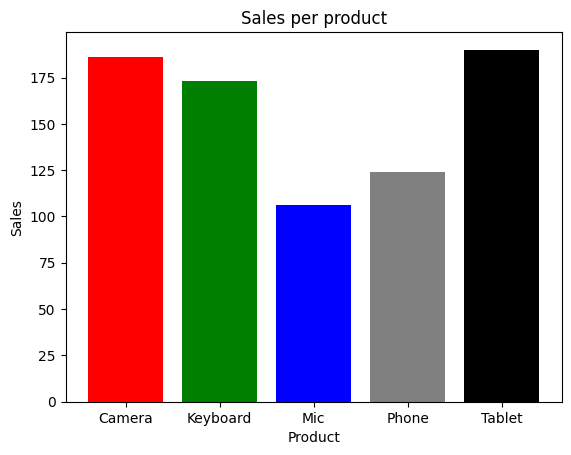

In [10]:
plt.bar(sales.index, sales.values, color=["red", "green", "blue", "gray", "black"])
plt.title("Sales per product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

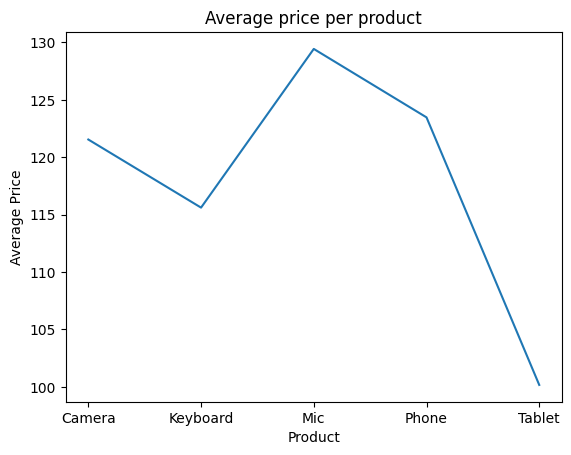

In [11]:
plt.plot(avg_prices.index, avg_prices.values)
plt.title("Average price per product")
plt.xlabel("Product")
plt.ylabel("Average Price")
plt.show()